In [303]:
import numpy as np
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt

from os import path

dirname = '/Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Mesa et al/Lineage models/Annotability results'

In [304]:
ALL_features_correlations_ALL_DELAYS = pd.read_csv(path.join(dirname,'not_aligned/ALL_features_correlations_ALL_DELAYS (1).csv'),index_col=0)
feature_correlation_heatmap = pd.read_csv(path.join(dirname,'not_aligned/feature_correlation_heatmap (2).csv'),index_col=0)
top_correlated_features_ALL_DELAYS = pd.read_csv(path.join(dirname,'not_aligned/top_correlated_features_ALL_DELAYS (9).csv'),index_col=0)


<Axes: xlabel='Confidence_Correlation', ylabel='Variability_Correlation'>

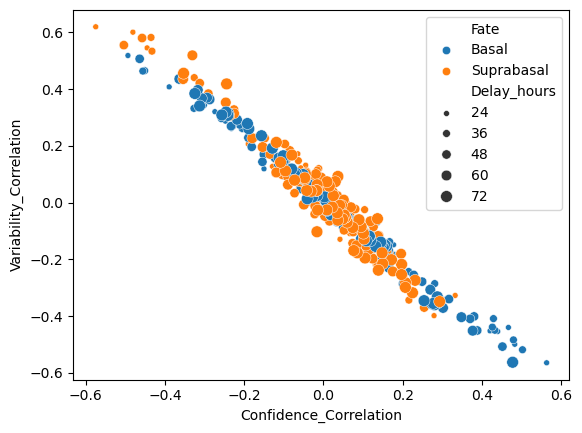

In [305]:
# df = ALL_features_correlations_ALL_DELAYS[ALL_features_correlations_ALL_DELAYS['Var_Significant'] & \
#                                         ALL_features_correlations_ALL_DELAYS['Conf_Significant'] &
#                                         (ALL_features_correlations_ALL_DELAYS['Variability_Correlation'] > 0)]
# df = ALL_features_correlations_ALL_DELAYS.reset_index().set_index('Fate').loc['Basal']
# sb.lineplot(df,x='Delay_hours',y='Confidence_Correlation',hue='Feature')

sb.scatterplot(ALL_features_correlations_ALL_DELAYS,x='Confidence_Correlation',y='Variability_Correlation',size='Delay_hours',hue='Fate')
# ALL_features_correlations_ALL_DELAYS

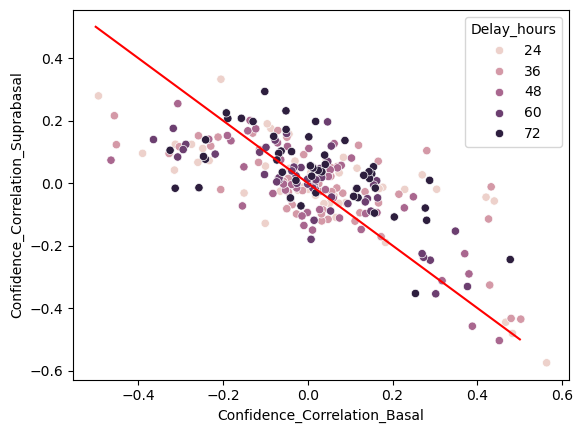

In [422]:
x = ALL_features_correlations_ALL_DELAYS.reset_index().set_index('Fate').loc['Basal'].set_index(['Feature','Delay_hours'])
y = ALL_features_correlations_ALL_DELAYS.reset_index().set_index('Fate').loc['Suprabasal'].set_index(['Feature','Delay_hours'])

df = pd.merge(x,y,left_index=True,right_index=True,suffixes=['_Basal','_Suprabasal'])
sb.scatterplot(df.reset_index(),x='Confidence_Correlation_Basal',y='Confidence_Correlation_Suprabasal',
               hue='Delay_hours')

plt.plot([-.5,.5],[.5,-.5],color='r')

In [445]:
supra_confR.sort_values()

Feature
shcoeff_PC5                             -0.443785
Mean curvature - cell coords            -0.389901
Basal area                              -0.251409
Mean curvature 2um                      -0.165640
Distance to closest macrophage          -0.136804
Mean curvature 5um                      -0.120049
Y-pixels                                -0.066362
Y                                       -0.066362
Nuclear solidity                        -0.047916
Mean curvature 15um                     -0.046097
Nuclear height                          -0.039595
Gaussian curvature 5um                  -0.034755
Gaussian curvature 2um                  -0.033665
shcoeff_PC0                             -0.031281
Mean curvature 10um                     -0.030164
shcoeff_PC8                             -0.024346
Gaussian curvature 15um                 -0.019279
BM height                               -0.019097
Gaussian curvature 10um                 -0.017543
nuc_shcoeffs_surface_area               -0

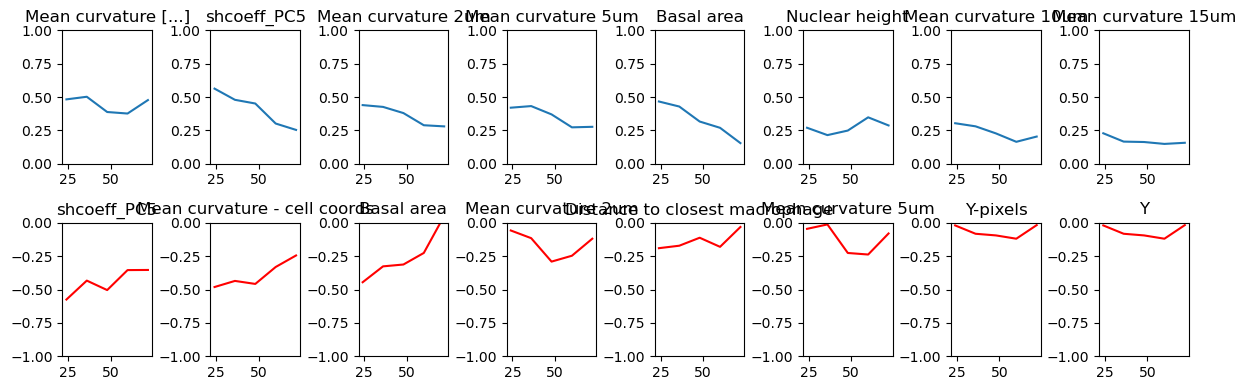

In [462]:

import textwrap

ALL_features_correlations_ALL_DELAYS = ALL_features_correlations_ALL_DELAYS.reset_index().set_index(['Feature','Delay_hours'])
ALL_features_correlations_ALL_DELAYS_basal = ALL_features_correlations_ALL_DELAYS[ALL_features_correlations_ALL_DELAYS['Fate'] == 'Basal']
ALL_features_correlations_ALL_DELAYS_suprabasal = ALL_features_correlations_ALL_DELAYS[ALL_features_correlations_ALL_DELAYS['Fate'] == 'Suprabasal']

basal_confR = ALL_features_correlations_ALL_DELAYS_basal.reset_index().groupby('Feature')['Confidence_Correlation'].mean()
supra_confR = ALL_features_correlations_ALL_DELAYS_suprabasal.reset_index().groupby('Feature')['Confidence_Correlation'].mean()


x = [24,36,48,60,72]
fig = plt.figure(figsize=[12,4])
Ncol = 8
for i in range(Ncol):
    
    plt.subplot(2,Ncol,i+1)
    f = basal_confR.sort_values(ascending=False).head(10).index.values[i]
    plt.plot(ALL_features_correlations_ALL_DELAYS_basal.loc[f,:]['Confidence_Correlation'])
    plt.ylim([0,1])
    plt.title(textwrap.shorten(f,20))
    
    plt.subplot(2,Ncol,i+Ncol+1)
    f = supra_confR.sort_values(ascending=True).head(10).index.values[i]
    plt.plot(ALL_features_correlations_ALL_DELAYS_suprabasal.loc[f,:]['Confidence_Correlation'],color='r')
    plt.ylim([-1,0])
    plt.title(textwrap.shorten(f,30))

fig.tight_layout()  
fig.savefig('/Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Mesa et al/Lineage models/Annotability results/not_aligned/top10_confidence_correlated.svg')


In [460]:
ALL_features_correlations_ALL_DELAYS.loc['Mean curvature 5um',:].sort_values('Fate')

,Fate,Confidence_Correlation,Confidence_Pvalue,Variability_Correlation,Variability_Pvalue,Conf_Significant,Var_Significant
Delay_hours,,,,,,,
24,Basal,0.420284,3.837774e-298,-0.452209,0.000000e+00,True,True
36,Basal,0.432339,3.048317e-261,-0.450081,1.378262e-285,True,True
48,Basal,0.370064,1.504370e-151,-0.409922,8.666608e-189,True,True
60,Basal,0.273076,2.356158e-66,-0.358136,4.612455e-116,True,True
72,Basal,0.276980,1.575496e-56,-0.355443,2.305845e-94,True,True
24,Suprabasal,-0.045074,3.130207e-01,0.131881,3.042947e-03,False,True
36,Suprabasal,-0.012001,7.946147e-01,0.119833,9.088506e-03,False,True
48,Suprabasal,-0.225874,3.177755e-06,0.327964,6.511140e-12,True,True
60,Suprabasal,-0.237467,2.530017e-06,0.305959,9.155889e-10,True,True


# 2. Cell cycle aligned

['Both Suprabasal (2)' 'Asymmetric (1)' 'Both Basal (0)' 'ALL']


<Axes: xlabel='Delay_hours', ylabel='Variability_Correlation'>

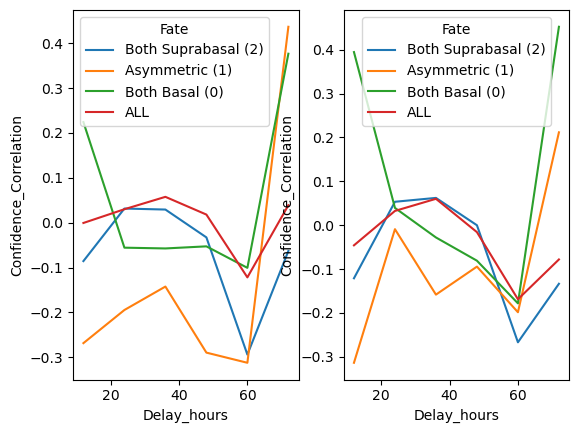

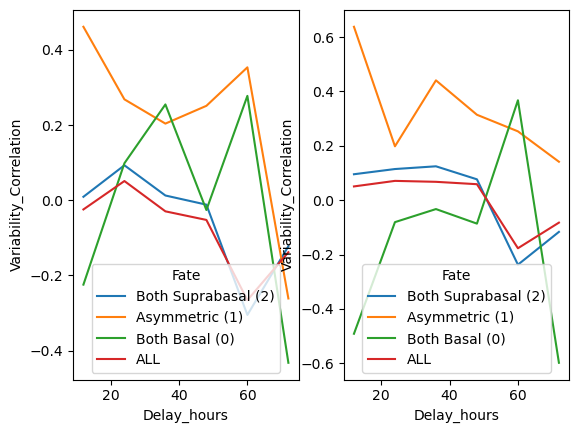

In [188]:
correlations = pd.read_csv(path.join(dirname,'aligned/correlation_results/correlations_ALL_TIMEPOINTS_full.csv'),index_col=0)
print(correlations['Fate'].unique())
correlations

# correlations.reset_index().set_index('Feature').loc['Mean curvature 5um_Measurement tissue geometry'].set_index('Fate').loc['Both Basal (0)']

plt.figure()
plt.subplot(1,2,1)
sb.lineplot(correlations.reset_index().set_index('Feature').loc['Mean curvature 5um_Measurement tissue geometry'],
            x='Delay_hours',y='Confidence_Correlation',hue='Fate')
plt.subplot(1,2,2)
sb.lineplot(correlations.reset_index().set_index('Feature').loc['Mean curvature 10um_Measurement tissue geometry'],
            x='Delay_hours',y='Confidence_Correlation',hue='Fate')

plt.figure()
plt.subplot(1,2,1)
sb.lineplot(correlations.reset_index().set_index('Feature').loc['Mean curvature 5um_Measurement tissue geometry'],
            x='Delay_hours',y='Variability_Correlation',hue='Fate')
plt.subplot(1,2,2)
sb.lineplot(correlations.reset_index().set_index('Feature').loc['Mean curvature 10um_Measurement tissue geometry'],
            x='Delay_hours',y='Variability_Correlation',hue='Fate')

In [201]:
# Low variability
df = correlations[correlations['Variability_Pvalue'] > 0.05]
df.reset_index().set_index('Fate').loc['Both Basal (0)'].sort_values('Confidence_Pvalue').head(50)

,Delay_hours,Feature,Confidence_Correlation,Confidence_Pvalue,Variability_Correlation,Variability_Pvalue
Fate,,,,,,
Both Basal (0),72,Median adjac BM height_Measurement tissue geom...,-0.535473,0.007006,0.312956,0.136483
Both Basal (0),72,Mean adjac BM height_Measurement tissue geomet...,-0.522784,0.008766,0.293439,0.164022
Both Basal (0),72,Min adjac Height to BM_Measurement tissue geom...,-0.519130,0.009336,0.374783,0.071159
Both Basal (0),72,BM height_Measurement tissue geometry,-0.510059,0.010885,0.293562,0.163837
Both Basal (0),72,Std adjac Gaussian curvature 15um_Measurement ...,0.500000,0.012845,-0.373913,0.071870
Both Basal (0),72,Relative Total H2B intensity_Measurement H2B r...,0.493913,0.014166,-0.267826,0.205764
Both Basal (0),72,shcoeff_PC2_Measurement shcoeff_PCA,0.478261,0.018081,-0.206087,0.333972
Both Basal (0),72,Mean adjac Height to BM_Measurement tissue geo...,-0.477391,0.018322,0.356522,0.087253
Both Basal (0),72,Max adjac BM height_Measurement tissue geometr...,-0.476173,0.018664,0.256401,0.226512
